#Prepare the environment and create the ontology

In [1]:
%pip install owlready2 # Install owllready2
import os
from datetime import datetime

def install_java():
  !apt-get install -y openjdk-8-jdk-headless -qq > /dev/null        #install openjdk
  os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"     #set environment variable
  !java -version                                                    #check java version
install_java()

!rm -rf /content/*.     # delete previous content of the directory
!git clone https://github.com/CMCosta/SULO-health-data-modelling.git # download necessary libraries from github repo
%cd /content/SULO-health-data-modelling

import sys
sys.path.insert(0, os.getcwd()) # add the current directory to the Python path

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 37.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for owlready2: filename=owlready2-0.50-cp312-cp312-linux_x86_64.whl size=24567083 sha256=aa2685592754d3f633db6db780f91b8332303dc4b6c531be9747fbaad4b9dccb
  Stored in directory: /root/.cache/pip/wheels/fb/9d/9d/24582de3856fe0ff897408eb6ed1baa6cd5b7b112a2b9c711c
Successfully built owlready2
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
Cloning into 'SULO-health-data-modelling'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 24 (delta 7), reused 10 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 37.55 MiB | 40.

In [2]:
from owlready2 import *
from lib.helpers import *


# Load SULO ontology (assuming it's accessible at this URI)
sulo = get_ontology("https://w3id.org/sulo/sulo.owl").load()

# Define the new Healthcare-related extension ontology
tutorial = get_ontology("https://w3id.org/sulo/extension/healthcare/cancer")
tutorial.imported_ontologies.append(sulo)

# EXERCISE 1: Medical Procedure & Observation result

On 2026-02-18, the **patient** Mary presented to the **outpatient gynecology clinic** of Dr. Smith for a **routine examination**. A physical examination was performed, including a **breast examination**. On palpation, a **breast lump** was detected in the **left breast**.

In [3]:
with tutorial:
    class SCT_HospitalBasedOutpatientGynecologyClinic(sulo.SpatialObject):
        pass
    class SCT_ManualBreastExamination(sulo.Process):
        pass
    class SCT_RoutineGynecologicExamination(sulo.Process):
        pass
    class SCT_BreastLump(sulo.Process):
        pass
    class SCT_LeftBreast(sulo.SpatialObject):
        pass
    class SCT_Person(sulo.SpatialObject):
        pass
    class SCT_Gynecologist(sulo.Role):
        pass
    class SCT_Planned(sulo.Quality):
        pass

In [4]:
with tutorial:
    # instance of manual breast examination process
    man_bre_exa_proc_1 = SCT_ManualBreastExamination("man_bre_exa_proc_1")
    man_bre_exa_proc_1.comment.append("Manual breast examination process")

    # instance of patient Mary
    pat_mary_spo = SCT_Person("pat_mary_spo")
    pat_mary_spo.comment.append("Person Mary")
    pat_mary_role = sulo.Role("pat_mary_role")
    pat_mary_role.comment.append("Patient role")
    pat_mary_spo.hasFeature = [pat_mary_role]

	# instance of gynecologist Dr. Smith
    gyn_smith_spo = SCT_Person("gyn_smith_spo")
    gyn_smith_spo.comment.append("Person Dr. Smith")
    gyn_smith_role = SCT_Gynecologist("smith_gyn_role")
    gyn_smith_role.comment.append("Gynecologist role")
    gyn_smith_spo.hasFeature = [gyn_smith_role]

    # Both, the gynecologist and the patient are process participants
    man_bre_exa_proc_1.hasParticipant = [pat_mary_role, gyn_smith_role]

    # time of the examination
    man_bre_exa_tinst_1 = sulo.TimeInstant("man_bre_exa_tinst_1")
    man_bre_exa_tinst_1.comment.append("Date time of the manual breast examination")
    man_bre_exa_tinst_1.hasValue = datetime.datetime(2026,2,18,0,0)
    man_bre_exa_proc_1.atTime = [man_bre_exa_tinst_1]

    # the physical location where the examination happened
    hosp_out_gyn_cli_spo_1 = SCT_HospitalBasedOutpatientGynecologyClinic("hosp_out_gyn_cli_spo_1")
    hosp_out_gyn_cli_spo_1.comment.append("Outpatient gynecology clinic")
    man_bre_exa_proc_1.isIn = [hosp_out_gyn_cli_spo_1]

    # the reason why the examination was done
    rou_gyn_exa_proc_1 = SCT_RoutineGynecologicExamination("rou_gyn_exa_proc_1")
    rou_gyn_exa_proc_1.comment.append("Routine Gynecologic Examination")
    planned_rou_gyn_qual_1 = SCT_Planned("planned_rou_gyn_qual_1")
    planned_rou_gyn_qual_1.comment.append("Planned quality")


    # plan to perform a routine gyn exam
    plan_rou_gyn_exa_io_1 = sulo.InformationObject("plan_rou_gyn_exa_io_1")
    plan_rou_gyn_exa_io_1.comment.append("Plan to perform a routine gynecologic examination")
    plan_rou_gyn_exa_io_1.refersTo = [rou_gyn_exa_proc_1]
    plan_rou_gyn_exa_io_1.hasFeature = [planned_rou_gyn_qual_1]

    #the plan has the role “reason” in the manual breast examination
    rou_gyn_exa_reason_role_1 = sulo.Role("rou_gyn_exa_reason_role_1")
    rou_gyn_exa_reason_role_1.comment.append("Reason role")
    rou_gyn_exa_reason_role_1.isFeatureOf = [plan_rou_gyn_exa_io_1]
    rou_gyn_exa_reason_role_1.isParticipantIn = [man_bre_exa_proc_1]

    # left breast lump
    lef_bre_spo_1 = SCT_LeftBreast("lef_bre_pro_1")
    lef_bre_spo_1.comment.append("Left breast")
    lef_bre_lum_pro_1 = SCT_BreastLump("lef_bre_lum_pro_1")
    lef_bre_lum_pro_1.comment.append("Left breast lump")
    lef_bre_lum_pro_1.isIn = [lef_bre_spo_1]

    # observation made as result of the exam
    stmt_lef_bre_lum_io_1 = sulo.InformationObject("stmt_lef_bre_lum_io_1")
    stmt_lef_bre_lum_io_1.comment.append("Statement about the patient having a left breast lump")
    stmt_lef_bre_lum_io_1.refersTo = [lef_bre_lum_pro_1]

    #the stmt has the role “output” in the manual breast examination
    stmt_lef_bre_lum_output_role_1 = sulo.Role("stmt_lef_bre_lum_output_role_1")
    stmt_lef_bre_lum_output_role_1.comment.append("Output role")
    stmt_lef_bre_lum_output_role_1.isFeatureOf = [stmt_lef_bre_lum_io_1]
    stmt_lef_bre_lum_output_role_1.isParticipantIn = [man_bre_exa_proc_1]


Display your data graph:

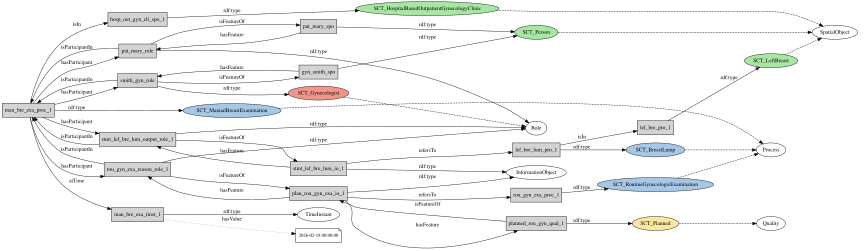

In [ ]:
my_graph1 = draw_instance_graph(tutorial)
my_graph1

# EXERCISE 2: Medical Procedure & Observation result (Your turn!!)

On 2026-02-20, an **ultrasound of left breast** is performed. The **radiologist** (Dr. Miller) interprets the images and he observes a suspicious mass in the **left breast** that he documents as a **tumor finding**.

Display your data graph:

In [ ]:
my_graph2 = draw_instance_graph(tutorial)
my_graph2

# EXERCISE 3: Diagnosed condition

Based on the clinical examination and imaging findings, on the 2026-02-22 Dr. Smith records a suspected **breast cancer**, as a **provisional/ preliminary diagnosis**, pending histopathological confirmation.

In [ ]:
with tutorial:
    class SCT_MalignantNeoplasmOfBreast (sulo.Process):
        pass
    class SCT_PreliminaryDiagnosis(sulo.Quality):
        pass
    class SCT_DiagnosticAssessment(sulo.Process):
        pass

In [ ]:
with tutorial:
    # instance of diagnostic process/assessment
    diag_proc_1 = SCT_DiagnosticAssessment("diag_proc_1")
    diag_proc_1.comment.append("Diagnostic process")

    # Both, the gynecologist and the patient are process participants
    diag_proc_1.hasParticipant = [pat_mary_role, gyn_smith_role]

    # time of the diagnosis
    diag_tinst_1 = sulo.TimeInstant("diag_tinst_1")
    diag_tinst_1.comment.append("Diagnosis date time")
    diag_tinst_1.hasValue = datetime.datetime(2026,2,22,0,0)
    diag_proc_1.atTime = [diag_tinst_1]

    # instance of the condition
    mal_neo_bre_cond_1 = SCT_MalignantNeoplasmOfBreast("mal_neo_bre_cond_1")
    mal_neo_bre_cond_1.comment.append("Malignant neoplasm of breast condition")

    # diagnostic statement
    stmt_mal_neo_bre_io_1 = sulo.InformationObject("stmt_mal_neo_bre_io_1")
    stmt_mal_neo_bre_io_1.comment.append("statement about malignant neoplasm of breast")
    stmt_mal_neo_bre_io_1.refersTo = [mal_neo_bre_cond_1]

    # preliminary diagnostic
    pre_diag_qual_1 = SCT_PreliminaryDiagnosis("pre_diag_qual_1")
    pre_diag_qual_1.comment.append("Preliminary diagnosis qualifier")
    stmt_mal_neo_bre_io_1.hasFeature = [pre_diag_qual_1]

    # The statement referring to the neoplasm is the result of the diagnostic assessment
    stmt_mal_neo_bre_output_role_1 = sulo.Role("stmt_mal_neo_bre_output_role_1")
    stmt_mal_neo_bre_output_role_1.comment.append("Output role of the statement about malignant neoplasm breast in the diagnosis")
    stmt_mal_neo_bre_output_role_1.isFeatureOf = [stmt_mal_neo_bre_io_1]
    stmt_mal_neo_bre_output_role_1.isParticipantIn = [diag_proc_1]


    # The statement referring to the tumor is the evidence or reason for this diagnosis
    stmt_tumor_reason_role_1 = sulo.Role("stmt_tumor_reason_role_1")
    stmt_tumor_reason_role_1.comment.append("Reason role of the statement about tumor finding in the diagnosis")
    stmt_tumor_reason_role_1.isFeatureOf = [stmt_tumor_io_1]
    stmt_tumor_reason_role_1.isParticipantIn = [diag_proc_1]

Display your data graph:

In [ ]:
my_graph3 = draw_instance_graph(tutorial)
my_graph3

# EXERCISE 4: Medical Procedure & Spatial Object as result

On 2026-02-25, a **biopsy of the left breast** is performed. A **specimen from the left breast** obtained by biopsy is produced and submitted for pathological examination.

In [ ]:
with tutorial:
    class SCT_BiopsyOfBreast (sulo.Process):
        pass
    class SCT_SpecimenBreastObtainedByBiopsy(sulo.SpatialObject):
        pass

In [ ]:
# instance of the biopsy of left breast
bio_lef_bre_proc_1 = SCT_BiopsyOfBreast("bio_lef_bre_proc_1")
bio_lef_bre_proc_1.comment.append("Biopsy of the left breast")
bio_lef_bre_proc_1.hasParticipant = [lef_bre_spo_1]

# Both, the gynecologist and the patient are process participants
bio_lef_bre_proc_1.hasParticipant = [pat_mary_role, gyn_smith_role]

# time of the biopsy
bio_bre_tinst_1 = sulo.TimeInstant("bio_bre_tinst_1")
bio_bre_tinst_1.comment.append("Date time of the biopsy")
bio_bre_tinst_1.hasValue = datetime.datetime(2026,2,25,0,0)
bio_lef_bre_proc_1.atTime = [bio_bre_tinst_1]

# specimen from the breast
spe_bre_by_bio_spo_1 = SCT_SpecimenBreastObtainedByBiopsy("spe_bre_by_bio_spo_1")
spe_bre_by_bio_spo_1.comment.append("Specimen of the breast obtained by biopsy")

# the breast specimen is participant in the biopsy, being a result
spe_bre_by_bio_output_role_1 = sulo.Role("output_role_3")
spe_bre_by_bio_output_role_1.comment.append("The specimen has the output role in the biopsy")
spe_bre_by_bio_output_role_1.isFeatureOf = [spe_bre_by_bio_spo_1]
spe_bre_by_bio_output_role_1.isParticipantIn = [bio_lef_bre_proc_1]


Display your data graph:

In [ ]:
my_graph4 = draw_instance_graph(tutorial)
my_graph4

# EXERCISE 5: Medical Procedure & Measurement results

On 2026-03-01, a **pathological analysis** was performed. **Tumor grade 2** was determined. Receptor status was also assessed during the pathological analysis.
**Estrogen receptor status was positive**. **Progesterone receptor status was positive. HER2 status was negative**.

In [ ]:
with tutorial:
    class SCT_HistopathologyTest(sulo.Process):
        pass
    class SCT_HistologicGradeOfNeoplasm (sulo.InformationObject):
        pass
    class SCT_PresenceOfERInNeoplasm(sulo.InformationObject):
        pass
    class SCT_PresenceOfPRInNeoplasm(sulo.InformationObject):
        pass
    class SCT_PresenceOfHER2InNeoplasm(sulo.InformationObject):
        pass

In [ ]:
with tutorial:
    # instance of the histopathology test on the specimen
    his_test_proc_1 = SCT_HistopathologyTest("his_test_proc_1")
    his_test_proc_1.comment.append("Histopathology test")
    his_test_proc_1.hasParticipant = [spe_bre_by_bio_spo_1, pat_mary_role]

    # time of the histopathology test
    his_test_tinst_1 = sulo.TimeInstant("his_test_tinst_1")
    his_test_tinst_1.comment.append("Histopathology test date time")
    his_test_tinst_1.hasValue = datetime.datetime(2026,3,1,0,0)
    his_test_proc_1.atTime = [his_test_tinst_1]

    # Tumor grade 2
    his_gra_neo_io_1 = SCT_HistologicGradeOfNeoplasm("his_gra_neo_qual_1")
    his_gra_neo_io_1.comment.append("Information about the histologic grade of neoplasm")
    his_gra_neo_io_1.hasValue = int(2)

    # tumor grade is a result of the histopathology test
    his_gra_neo_output_role_1 = sulo.Role("his_gra_neo_output_role_1")
    his_gra_neo_output_role_1.comment.append("Output role of the neoplasm grade of the pathology test")
    his_gra_neo_output_role_1.isFeatureOf = [his_gra_neo_io_1]
    his_gra_neo_output_role_1.isParticipantIn = [his_test_proc_1]

    # Lab result ER positive
    pre_er_neo_io_1 = SCT_PresenceOfERInNeoplasm("stmt_pre_er_neo_qty_1")
    pre_er_neo_io_1.comment.append("Information about the presence of ER in neoplasm")
    pre_er_neo_io_1.hasValue = int(1)

    # Lab result ER positive is a result of the histopathology test
    pre_er_neo_output_role_1 = sulo.Role("pre_er_neo_output_role_1")
    pre_er_neo_output_role_1.comment.append("Output role of the ER presence in the pathology test")
    pre_er_neo_output_role_1.isFeatureOf = [pre_er_neo_io_1]
    pre_er_neo_output_role_1.isParticipantIn = [his_test_proc_1]

    # Lab result PR positive
    pre_pr_neo_io_1 = SCT_PresenceOfPRInNeoplasm("pre_pr_neo_io_1")
    pre_pr_neo_io_1.comment.append("Information about the presence of PR in neoplasm")
    pre_pr_neo_io_1.hasValue = int(1)

    # Lab result PR positive is a result of the histopathology test
    pre_pr_neo_output_role_1 = sulo.Role("pre_pr_neo_output_role_1")
    pre_pr_neo_output_role_1.comment.append("Output role of the PR presence in the pathology test")
    pre_pr_neo_output_role_1.isFeatureOf = [pre_pr_neo_io_1]
    pre_pr_neo_output_role_1.isParticipantIn = [his_test_proc_1]

    # Lab result HER2 negative
    pre_her2_neo_io_1 = SCT_PresenceOfHER2InNeoplasm("pre_her2_neo_qty_1")
    pre_her2_neo_io_1.comment.append("Information about the presence of HER2 in neoplasm")
    pre_her2_neo_io_1.hasValue = int(0)

    # Lab result HER2 negative is a result of the histopathology test
    pre_her2_neo_output_role_1 = sulo.Role("pre_her2_neo_output_role_1")
    pre_her2_neo_output_role_1.comment.append("Output role of the HER2 presence in the pathology test")
    pre_her2_neo_output_role_1.isFeatureOf = [pre_her2_neo_io_1]
    pre_her2_neo_output_role_1.isParticipantIn = [his_test_proc_1]



Display your data graph:

In [ ]:
my_graph5 = draw_instance_graph(tutorial)
my_graph5

# EXERCISE 6: Diagnosed condition (Your turn!!)

The **pathological analysis** on 2026-03-01 **confirms the diagnosis of invasive carcinoma of the left breast**.


Display your data graph:

In [ ]:
my_graph6 = draw_instance_graph(tutorial)
my_graph6

# EXERCISE 7: Medical Treatment

From 2026-03-10 to 2026-06-15, the patient undergoes **neoadjuvant antineoplastic chemotherapy** consisting of **doxorubicin** and **cyclophosphamide** followed by **paclitaxel** (**AC-T regimen**).


In [ ]:
with tutorial:
    class SCT_NeoadjuvantAntineoplasticChemotherapy (sulo.Process):
        pass
    class SCT_Doxorubicin(sulo.SpatialObject):
        pass
    class SCT_Cyclophosphamide(sulo.SpatialObject):
        pass
    class SCT_Paclitaxel(sulo.SpatialObject):
        pass

In [ ]:
with tutorial:
    # instance of the chemotherapy process
    neo_ant_chem_proc_1 = SCT_NeoadjuvantAntineoplasticChemotherapy("neo_ant_chem_proc_1")
    neo_ant_chem_proc_1.comment.append("Neoadjuvant antineoplastic chemotherapy")
    neo_ant_chem_proc_1.hasParticipant = [pat_mary_role]

    # start time of the chemotherapy
    neo_ant_chem_stime_1 = sulo.StartTime("neo_ant_chem_stime_1")
    neo_ant_chem_stime_1.comment.append("Start time of the chemotherapy")
    neo_ant_chem_stime_1.hasValue = datetime.datetime(2026,3,10,0,0)
    neo_ant_chem_proc_1.atTime = [neo_ant_chem_stime_1]

    # end time of the chemotherapy
    neo_ant_chem_etime_1 = sulo.EndTime("neo_ant_chem_etime_1")
    neo_ant_chem_etime_1.comment.append("End time of the chemotherapy")
    neo_ant_chem_etime_1.hasValue = datetime.datetime(2026,6,15,0,0)
    neo_ant_chem_proc_1.atTime = [neo_ant_chem_etime_1]

    # instance of doxorubicin
    doxo_spo_1 = SCT_Doxorubicin("doxo_spo_1")
    doxo_spo_1.comment.append("Doxorubicin")
    # instance of cyclophosphamide
    cyphos_spo_1 = SCT_Cyclophosphamide("cyphos_spo_1")
    cyphos_spo_1.comment.append("Cyclophosphamide")
    # instance of paclitaxel
    pcltxl_spo_1 = SCT_Paclitaxel("pcltxl_spo_1")
    pcltxl_spo_1.comment.append("Paclitaxel")

    # The three of them have an agent role in the corresponding chemo process
    doxo_agent_role_1 = sulo.Role("doxo_agent_role_1")
    doxo_agent_role_1.comment.append("Doxorubicin agent role in chemotherapy")
    doxo_agent_role_1.isFeatureOf = [doxo_spo_1]

    cyphos_agent_role_1 = sulo.Role("cyphos_agent_role_1")
    cyphos_agent_role_1.comment.append("Cyclophosphamide agent role in chemotherapy")
    cyphos_agent_role_1.isFeatureOf = [cyphos_spo_1]

    pcltxl_agent_role_1 = sulo.Role("pcltxl_agent_role_1")
    pcltxl_agent_role_1.comment.append("Paclitaxel gent role in chemotherapy")
    pcltxl_agent_role_1.isFeatureOf = [pcltxl_spo_1]

    #AC regime
    neo_ant_chem_acreg_proc_1 = SCT_NeoadjuvantAntineoplasticChemotherapy("neo_ant_chem_acreg_proc_1")
    neo_ant_chem_acreg_proc_1.comment.append("AC regime chemotherapy")
    neo_ant_chem_acreg_proc_1.hasParticipant = [pat_mary_spo,doxo_agent_role_1,cyphos_agent_role_1]

    #T regime
    neo_ant_chem_treg_proc_1 = SCT_NeoadjuvantAntineoplasticChemotherapy("neo_ant_chem_treg_proc_1")
    neo_ant_chem_treg_proc_1.comment.append("R regime chemotherapy")
    neo_ant_chem_treg_proc_1.hasParticipant = [pat_mary_spo,pcltxl_agent_role_1]


    #AC-T regime (First AC, later T)
    neo_ant_chem_acreg_proc_1.precedes = [neo_ant_chem_treg_proc_1]

    #AC-T processes are part of the main chemo process
    neo_ant_chem_proc_1.hasPart = [neo_ant_chem_acreg_proc_1,neo_ant_chem_treg_proc_1]


Display my data graph:

In [ ]:
my_graph7 = draw_instance_graph(tutorial)
my_graph7

# EXERCISE 8: Medical Treatment (Your turn!!)

On 2026-07-01, surgical treatment is **performed** in the form of **lumpectomy of the left breast**

Display my data graph:

In [ ]:
my_graph8 = draw_instance_graph(tutorial)
my_graph8

# EXERCISE 9: Medical Procedure & Diagnosis

On 2026-09-30, **follow-up assessment** indicates **remission**.


In [ ]:
with tutorial:
    class SCT_FollowUpVisit(sulo.Process):
        pass
    class SCT_RemissionPhase(sulo.Quality):
        pass

In [ ]:
with tutorial:
    # instance of the follow-up visit
    follow_up_proc_1 = SCT_FollowUpVisit("follow_up_proc_1")
    follow_up_proc_1.comment.append("Follow-up visit")
    follow_up_proc_1.hasParticipant = [pat_mary_role, gyn_smith_role]

    # date time for the follow-up
    follow_up_tinst_1 = sulo.TimeInstant("follow_up_tinst_1 ")
    follow_up_tinst_1.comment.append("Date time of the follow-up visit")
    follow_up_tinst_1.hasValue = datetime.datetime(2026,9,30,0,0)
    follow_up_proc_1.atTime = [follow_up_tinst_1]

    # diagnosis in the follow-up
    diag_proc_3 = SCT_DiagnosticAssessment("diag_proc_3")
    diag_proc_3.comment.append("Diagnostic process")
    diag_proc_3.isPartOf = [follow_up_proc_1]

    # Both, the gynecologist and the patient are process participants
    diag_proc_3.hasParticipant = [pat_mary_role, gyn_smith_role]
    #the diagnostic process is part of the follow-up
    diag_proc_3.isPartOf = [follow_up_proc_1]

    # time of the diagnosis
    diag_tinst_3 = sulo.TimeInstant("diag_tinst_3")
    diag_tinst_3.comment.append("Date time of the diagnosis")
    diag_tinst_3.hasValue = datetime.datetime(2026,9,30,0,0)
    diag_proc_3.atTime = [diag_tinst_3]

    # instance of the condition
    inv_car_lef_bre_cond_2 = SCT_InvasiveCarcinomaOfBreast("inv_car_lef_bre_cond_2")
    inv_car_lef_bre_cond_2.comment.append("Invasive carcinoma of the left breast")
    inv_car_lef_bre_cond_2.isIn = [lef_bre_spo_1]

    # diagnostic statement
    stmt_inv_car_lef_bre_io_2 = sulo.InformationObject("stmt_inv_car_lef_bre_io_2")
    stmt_inv_car_lef_bre_io_2.comment.append("Statement about the patient having invasive carcinoma of left breast")
    stmt_inv_car_lef_bre_io_2.refersTo = [inv_car_lef_bre_cond_2]

    # output role of the diagnostic statement
    stmt_inv_car_lef_bre_output_role_2 = sulo.Role("stmt_inv_car_lef_bre_output_role_2")
    stmt_inv_car_lef_bre_output_role_2.comment.append("Output role of the diagnostic statement in the diagnosis process")
    stmt_inv_car_lef_bre_output_role_2.isFeatureOf = [stmt_inv_car_lef_bre_io_2]
    stmt_inv_car_lef_bre_output_role_2.isParticipantIn = [diag_proc_3]

    # disease in remission
    rem_phase_qual_1 = SCT_RemissionPhase("rem_phase_qual_1")
    rem_phase_qual_1.comment.append("Remission phase of the disease")
    inv_car_lef_bre_cond_2.hasFeature = [rem_phase_qual_1]



Display my data graph:

In [ ]:
my_graph9 = draw_instance_graph(tutorial)
my_graph9

# EXERCISE 10: Planned Procedure

A **follow-up visit is scheduled** for 01/01/2027.


In [ ]:
with tutorial:
    # instance of the follow-up visit
    follow_up_proc_2 = SCT_FollowUpVisit("follow_up_proc_2")
    follow_up_proc_2.comment.append("Follow-up visit")
    follow_up_proc_1.hasParticipant = [pat_mary_role, gyn_smith_role]

    # date time for the follow-up
    follow_up_tinst_2 = sulo.StartTime("follow_up_tinst_2")
    follow_up_tinst_2.comment.append("Date time of the planned follow up")
    follow_up_tinst_2.hasValue = datetime.datetime(2027,1,1,0,0)
    follow_up_proc_2.atTime = [follow_up_tinst_2]

    # plan for the follow-up
    planstmt_follow_up_io_2 = sulo.InformationObject("planstmt_follow_up_io_2")
    planstmt_follow_up_io_2.comment.append("Plan to do a follow-up")
    planstmt_follow_up_io_2.refersTo = [follow_up_proc_2]
    start_process_plan_io_2 = sulo.InformationObject("start_process_plan_io_2")
    start_process_plan_io_2.comment.append("Part of the plan which includes the start of the process at a particular time")
    planstmt_follow_up_io_2.hasPart = [start_process_plan_io_2]
    start_process_plan_io_2.hasPart = [follow_up_tinst_2]


Display my data graph:

In [ ]:
my_graph10 = draw_instance_graph(tutorial)
my_graph10

# Draw the final class hierarchy:

In [ ]:
health_class_tree = get_color_tree([sulo, tutorial])
print("Tutorial Class hierarchy")
display(health_class_tree)  # Class hierarchy

# Save the ontology:

In [ ]:
# Save the extended ontology as a Turtle file
tutorial.save(file = "my-tutorial-sulo.owl", format = "rdfxml")
print("Ontology saved to 'my-tutorial-sulo.owl' in OWL/XML format.")